In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from bart_playground import DefaultBART, ParallelTemperingBART, MultiBART, DataGenerator
from bart_playground.samplers import mtmh_proposal_probs
import cProfile
import pstats
import io
import time

In [3]:
# Benchmark settings split into default and MTMH proposal configs
default_proposal_probs = {"grow": 0.4, "prune": 0.4, "change": 0.1, "swap": 0.1}
mtmh_proposal_probs = {"multi_grow": 0.4, "multi_prune": 0.4, "multi_change": 0.1, "multi_swap": 0.1}
generator = DataGenerator(n_samples=1000, n_features=10, noise=0.1, random_seed=42)
X, y = generator.generate(scenario="heteroscedastic")
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

default_kwargs = dict(
    ndpost=800,
    nskip=200,
    n_trees=100,
    proposal_probs=default_proposal_probs,
    random_state=42,
    max_bins=100,
    tol=1,
    quick_decay=False,
    dirichlet_prior=False,
    temperature=1.0,
 )

# PT kwargs template (hard-coded temperatures set in next cell)
pt_kwargs = dict(
    ndpost=800,
    nskip=200,
    n_trees=100,
    proposal_probs=default_proposal_probs,
    random_state=42,
    max_bins=100,
    tol=1,
    quick_decay=False,
    dirichlet_prior=False,
    swap_interval=50,
    swap_sweeps=2,
    post_swap_repair_steps=0,
    store_chain_traces=False,
    store_swap_diagnostics=True,
    # print_swap_diagnostics=True,
    n_temperatures=8, max_temperature=5.0, 
    n_jobs=-1,
    local_move_backend="multiprocessing-pipe",  # or "joblib-loky"
 )

In [4]:
# initialize numba (warmup)
warmup_default = DefaultBART(ndpost=5, nskip=5, n_trees=20, proposal_probs=default_proposal_probs, random_state=7)
_ = warmup_default.fit(X_train[:800], y_train[:800], quietly=True)

warmup_pt = ParallelTemperingBART(
    ndpost=5, nskip=5, n_trees=20, proposal_probs=default_proposal_probs,
    random_state=7, n_temperatures=3, max_temperature=3.0, swap_interval=5
 )
_ = warmup_pt.fit(X_train[:800], y_train[:800], quietly=True)

print("Numba warmup completed.")

Numba warmup completed.


In [5]:
# Quick PT+MTMH smoke test: instantiate PT with MultiSampler and run small fit
pt_mtmh = ParallelTemperingBART(
    ndpost=10, nskip=0, n_trees=5, proposal_probs=mtmh_proposal_probs,
    random_state=7, n_temperatures=3, max_temperature=3.0, swap_interval=5,
    sampler_kind="multi", multi_tries=3
 )
pt_mtmh.fit(X_train[:200], y_train[:200], quietly=True)
print('Chain sampler types:', [type(s).__name__ for s in pt_mtmh.chain_samplers])
print('Trace length (cold chain):', len(pt_mtmh.trace))

Chain sampler types: ['MultiSampler', 'MultiSampler', 'MultiSampler']
Trace length (cold chain): 10


In [6]:
# helper: format cProfile output
def profile_summary(profiler, top_n=20, sort_key="cumtime"):
    s = io.StringIO()
    pstats.Stats(profiler, stream=s).sort_stats(sort_key).print_stats(top_n)
    return s.getvalue()

# helper: compare RMSE across trained models
def compare_rmse(models, X, y):
    import pandas as pd
    rows = []
    for name, model in models.items():
        rmse = root_mean_squared_error(y, model.predict(X))
        rows.append({"model": name, "rmse": rmse})
    return pd.DataFrame(rows).sort_values("rmse", ascending=True).reset_index(drop=True)

# --- DefaultBART fit + profile ---
default_model = DefaultBART(**default_kwargs)
default_profiler = cProfile.Profile()
t0 = time.perf_counter()
default_profiler.enable()
default_model.fit(X_train, y_train)
default_profiler.disable()
default_fit_seconds = time.perf_counter() - t0
default_profile_text = profile_summary(default_profiler, top_n=20)

# --- ParallelTemperingBART (standard PT) fit + profile ---
pt_model = ParallelTemperingBART(**pt_kwargs)
pt_profiler = cProfile.Profile()
t0 = time.perf_counter()
pt_profiler.enable()
pt_model.fit(X_train, y_train)
pt_profiler.disable()
pt_fit_seconds = time.perf_counter() - t0
pt_profile_text = profile_summary(pt_profiler, top_n=20)

# --- ParallelTemperingBART with MultiSampler (PT+MTMH) fit + profile ---
pt_mtmh_kwargs = dict(pt_kwargs)
pt_mtmh_kwargs["proposal_probs"] = mtmh_proposal_probs
pt_mtmh = ParallelTemperingBART(**pt_mtmh_kwargs, sampler_kind="multi")
pt_mtmh_profiler = cProfile.Profile()
t0 = time.perf_counter()
pt_mtmh_profiler.enable()
pt_mtmh.fit(X_train, y_train)
pt_mtmh_profiler.disable()
pt_mtmh_fit_seconds = time.perf_counter() - t0
pt_mtmh_profile_text = profile_summary(pt_mtmh_profiler, top_n=20)

# --- MultiBART (standard MTMH) fit + profile ---
multi_kwargs = dict(default_kwargs)
multi_kwargs["proposal_probs"] = mtmh_proposal_probs
multi_model = MultiBART(**multi_kwargs, multi_tries=10)
multi_profiler = cProfile.Profile()
t0 = time.perf_counter()
multi_profiler.enable()
multi_model.fit(X_train, y_train)
multi_profiler.disable()
multi_fit_seconds = time.perf_counter() - t0
multi_profile_text = profile_summary(multi_profiler, top_n=20)

# RMSE comparison via function (four-way comparison)
rmse_df = compare_rmse(
    {
        "default": default_model,
        "default_pt": pt_model,
        "mtmh": multi_model,
        "mtmh+pt": pt_mtmh,
    },
    X_test,
    y_test,
 )

# speed + rmse summary
import pandas as pd
fit_df = pd.DataFrame({
    "model": ["default", "default_pt", "mtmh+pt", "mtmh"],
    "fit_seconds": [default_fit_seconds, pt_fit_seconds, pt_mtmh_fit_seconds, multi_fit_seconds],
})
fit_df["speedup_vs_default"] = fit_df.loc[0, "fit_seconds"] / fit_df["fit_seconds"]

summary_df = fit_df.merge(rmse_df, on="model", how="left")
print(summary_df)

Iterations: 100%|██████████| 1000/1000 [01:17<00:00, 12.86it/s]


        model  fit_seconds  speedup_vs_default      rmse
0     default    14.664808            1.000000  1.899877
1  default_pt    56.247283            0.260720  1.841089
2     mtmh+pt   126.066002            0.116326  1.849164
3        mtmh    77.773867            0.188557  1.867980


In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

comparison_order = ["default", "default_pt", "mtmh", "mtmh+pt"]
comparison_models = {
    "default": default_model,
    "default_pt": pt_model,
    "mtmh": multi_model,
    "mtmh+pt": pt_mtmh,
}
comparison_colors = {
    "default": "tab:blue",
    "default_pt": "tab:orange",
    "mtmh": "tab:green",
    "mtmh+pt": "tab:red",
}

def posterior_pred_matrix(model, X):
    return np.stack([model.predict_trace(k, X) for k in model.range_post], axis=0)

comparison_pred_mats = {
    name: posterior_pred_matrix(model, X_test)
    for name, model in comparison_models.items()
}
comparison_pc1 = {
    name: PCA(n_components=1).fit_transform(pred_mat).ravel()
    for name, pred_mat in comparison_pred_mats.items()
}
comparison_sigma_traces = {
    name: np.array([np.asarray(t.global_params["eps_sigma2"]).ravel()[0] for t in model.trace])
    for name, model in comparison_models.items()
}

comparison_joint_preds = np.vstack([comparison_pred_mats[name] for name in comparison_order])
comparison_joint_labels = np.concatenate([
    np.repeat(name, comparison_pred_mats[name].shape[0])
    for name in comparison_order
])
comparison_pca2 = PCA(n_components=2, random_state=42)
comparison_joint_coords = comparison_pca2.fit_transform(comparison_joint_preds)
comparison_centroids = {
    name: comparison_joint_coords[comparison_joint_labels == name].mean(axis=0)
    for name in comparison_order
}

In [8]:
profile_text_map = {
    "default": default_profile_text,
    "default_pt": pt_profile_text,
    "mtmh": multi_profile_text,
    "mtmh+pt": pt_mtmh_profile_text,
}

for name in comparison_order:
    print(f"\n=== Top-20 cProfile ({name}) ===")
    print(profile_text_map[name])

default_pt_params = pt_model.get_params()
mtmh_pt_params = pt_mtmh.get_params()

print("\ndefault_pt temperatures:")
for i, t in enumerate(default_pt_params.get("temperatures", [])):
    print(f"chain {i}: T={t:.6g}")

print("\ndefault_pt swap stats:")
print(default_pt_params.get("swap_attempts"), default_pt_params.get("swap_accept_rates"))

print("\nmtmh+pt temperatures:")
for i, t in enumerate(mtmh_pt_params.get("temperatures", [])):
    print(f"chain {i}: T={t:.6g}")

print("\nmtmh+pt swap stats:")
print(mtmh_pt_params.get("swap_attempts"), mtmh_pt_params.get("swap_accept_rates"))


=== Top-20 cProfile (default) ===
         7704249 function calls in 14.665 seconds

   Ordered by: cumulative time
   List reduced from 539 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000   14.665    7.332 c:\Users\ztykk\Phd\BART\bart-playground\.venv\lib\site-packages\IPython\core\interactiveshell.py:3543(run_code)
        2    0.000    0.000   14.665    7.332 {built-in method builtins.exec}
        1    0.000    0.000   14.665   14.665 C:\Users\ztykk\Phd\BART\bart-playground\bart_playground\bart.py:193(fit)
        1    0.000    0.000   14.661   14.661 C:\Users\ztykk\Phd\BART\bart-playground\bart_playground\bart.py:200(fit_with_data)
        1    0.055    0.055   14.661   14.661 C:\Users\ztykk\Phd\BART\bart-playground\bart_playground\samplers.py:93(run)
     1000    1.095    0.001   13.872    0.014 C:\Users\ztykk\Phd\BART\bart-playground\bart_playground\samplers.py:351(one_iter)
   100000    0.252   

In [ ]:
print("\nPT swap stats (attempt/accept rate by adjacent pair):")
print(pt_params.get("swap_attempts"), pt_params.get("swap_accept_rates"))

diags = pt_params.get("swap_diagnostics", None)
if not diags:
    print("\nNo swap_diagnostics found. Set store_swap_diagnostics=True and rerun PT fit.")
else:
    import pandas as pd
    diag_df = pd.DataFrame(diags).copy()
    diag_df["accepted"] = diag_df["accepted"].astype(bool)

    # Keep key columns and sort so the swap schedule is easy to read
    show_cols = [
        "iteration", "swap_step", "sweep", "pair_index",
        "temp_a", "temp_b", "delta", "accepted",
    ]
    for c in ["iteration", "swap_step", "sweep", "pair_index"]:
        if c in diag_df.columns:
            diag_df[c] = diag_df[c].astype("Int64")

    diag_view = diag_df[show_cols].sort_values(["iteration", "sweep", "pair_index"]).reset_index(drop=True)

    print("\nSwap diagnostics preview (first 20 attempts):")
    print(diag_view.head(20))

    # Aggregate acceptance by sweep index inside each swap step
    by_sweep = (
        diag_df.groupby(["swap_step", "sweep", "pair_index"], as_index=False)
        .agg(attempts=("accepted", "size"), accepts=("accepted", "sum"))
    )
    by_sweep["accept_rate"] = by_sweep["accepts"] / by_sweep["attempts"]

    print("\nAcceptance by (swap_step, sweep, pair_index):")
    print(by_sweep.head(30))

    # Overall acceptance by sweep number (across all swap steps/pairs)
    sweep_summary = (
        diag_df.groupby("sweep", as_index=False)
        .agg(attempts=("accepted", "size"), accepts=("accepted", "sum"))
    )
    sweep_summary["accept_rate"] = sweep_summary["accepts"] / sweep_summary["attempts"]

    print("\nOverall acceptance by sweep index:")
    print(sweep_summary)

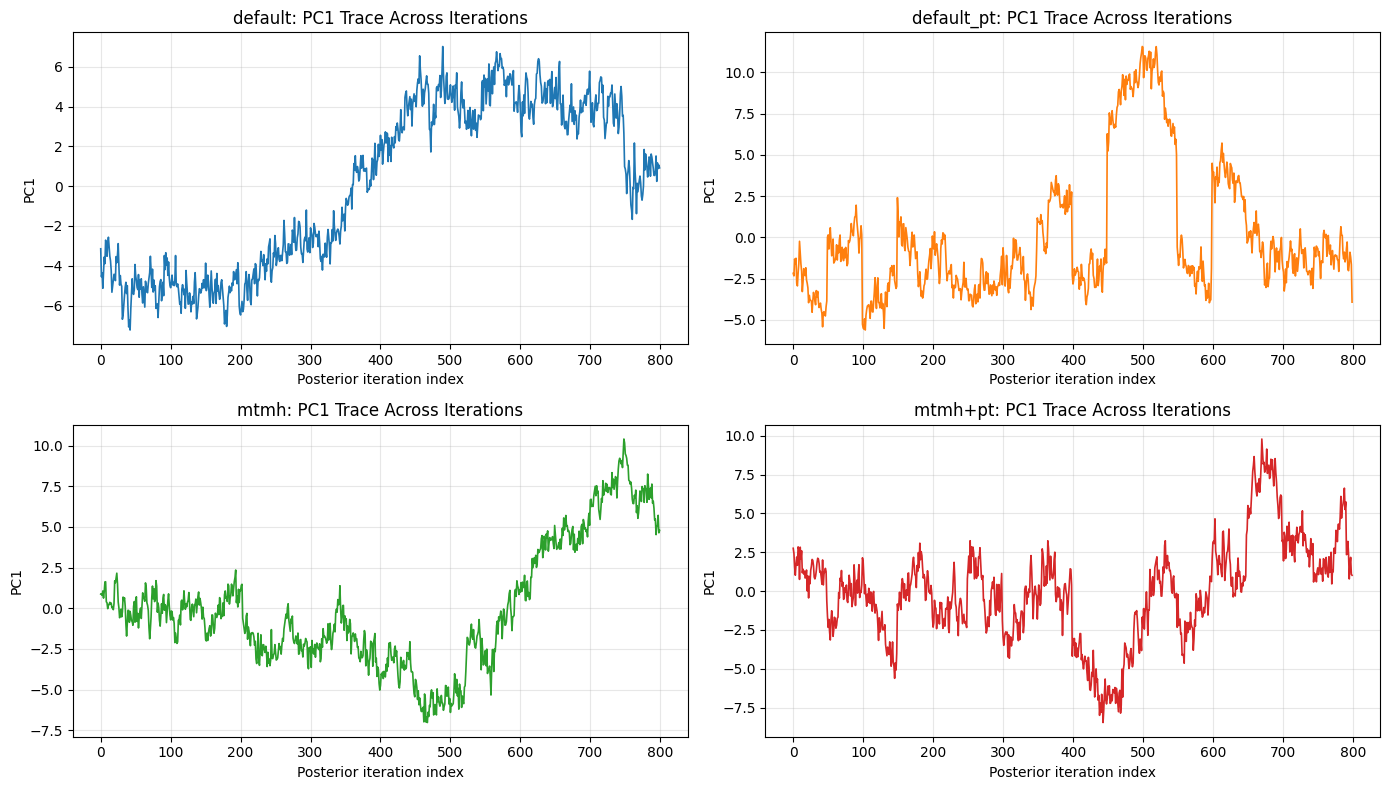

default pred matrix shape: (800, 250)
default_pt pred matrix shape: (800, 250)
mtmh pred matrix shape: (800, 250)
mtmh+pt pred matrix shape: (800, 250)


In [9]:
# Per-iteration prediction traces -> PCA(1D) -> trace plot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=False)
axes = axes.ravel()

for ax, name in zip(axes, comparison_order):
    ax.plot(comparison_pc1[name], lw=1.2, color=comparison_colors[name])
    ax.set_title(f"{name}: PC1 Trace Across Iterations")
    ax.set_xlabel("Posterior iteration index")
    ax.set_ylabel("PC1")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

for name in comparison_order:
    print(f"{name} pred matrix shape:", comparison_pred_mats[name].shape)

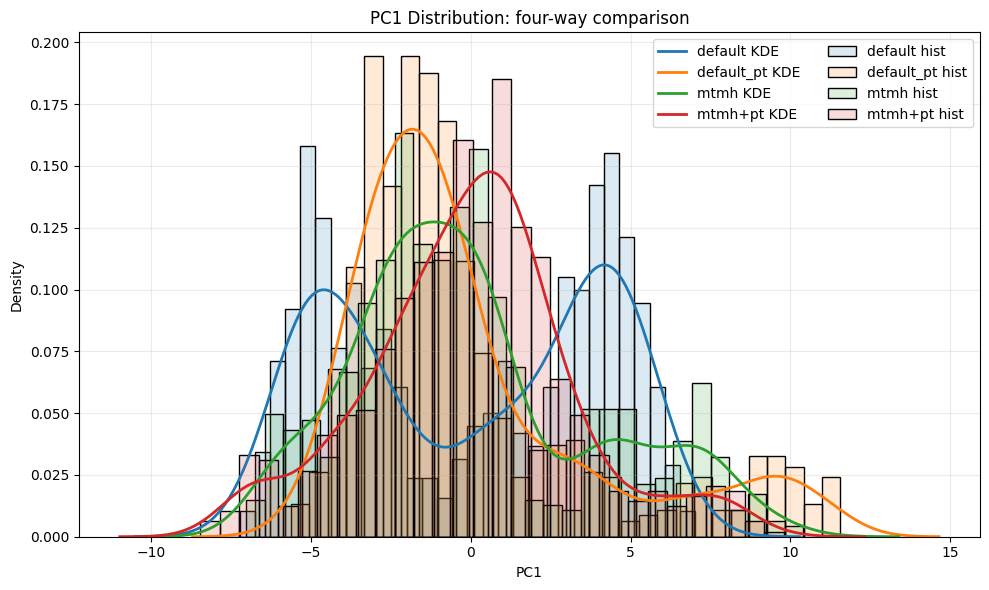

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Histogram (density) + KDE for each method
for name in comparison_order:
    sns.histplot(
        comparison_pc1[name],
        bins=30,
        stat="density",
        alpha=0.16,
        color=comparison_colors[name],
        label=f"{name} hist",
        ax=ax,
    )
    sns.kdeplot(
        comparison_pc1[name],
        color=comparison_colors[name],
        linewidth=2,
        label=f"{name} KDE",
        ax=ax,
    )

ax.set_title("PC1 Distribution: four-way comparison")
ax.set_xlabel("PC1")
ax.set_ylabel("Density")
ax.grid(alpha=0.25)
ax.legend(loc="best", ncol=2)
plt.tight_layout()
plt.show()

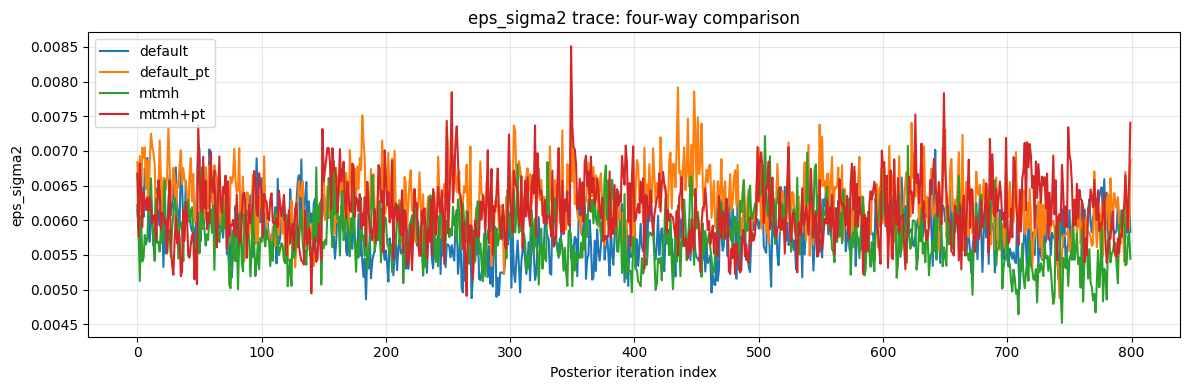

In [11]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 4))
for name in comparison_order:
    plt.plot(comparison_sigma_traces[name], label=name, color=comparison_colors[name])

plt.xlabel('Posterior iteration index')
plt.ylabel('eps_sigma2')
plt.title('eps_sigma2 trace: four-way comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

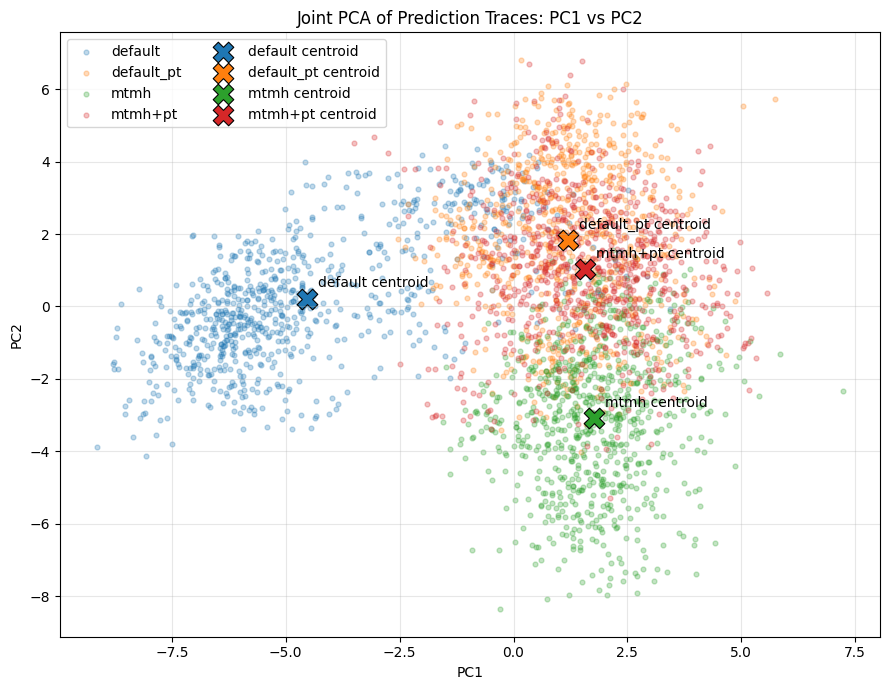

Explained variance ratio: [0.04578659 0.03378549]
default centroid: [-4.53964047  0.21878902]
default_pt centroid: [1.19936078 1.82489771]
mtmh centroid: [ 1.76607013 -3.07621193]
mtmh+pt centroid: [1.57420957 1.03252519]


In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 7))

for name in comparison_order:
    coords = comparison_joint_coords[comparison_joint_labels == name]
    ax.scatter(
        coords[:, 0], coords[:, 1],
        s=12, alpha=0.28, label=name, color=comparison_colors[name]
    )

# Mark centroids
for name in comparison_order:
    centroid = comparison_centroids[name]
    ax.scatter(
        centroid[0], centroid[1],
        s=220, marker="X", color=comparison_colors[name], edgecolor="black", linewidth=0.8,
        label=f"{name} centroid"
    )
    ax.annotate(
        f"{name} centroid",
        (centroid[0], centroid[1]),
        xytext=(8, 8),
        textcoords="offset points",
    )

ax.set_title("Joint PCA of Prediction Traces: PC1 vs PC2")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.3)
ax.legend(loc="best", ncol=2)
plt.tight_layout()
plt.show()

print("Explained variance ratio:", comparison_pca2.explained_variance_ratio_)
for name in comparison_order:
    print(f"{name} centroid:", comparison_centroids[name])